# Geocalibration

In addition to learning the rotation matrices $R^r_{r'}$ & $R^m_c$, we will learn the parameters $b_1$, $b_2$, $c_x$ and $c_y$.

In [1]:
data_fpath = "data/m41_site_cal_v229_v4.xlsx"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
from tqdm import tqdm
from typing import List
import json

In [3]:
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

# function for parsing data
def get_zl_zr(f_str:str, data:pd.DataFrame):
    """
    Extract the data for focus [f_str] for ZL and ZR cameras
    f_str: str, string of the focus number
    data: pd.DataFrame, the data
    """
    d_left = data[data["cam"]==f"ZL{f_str}"].copy().reset_index(drop=True)
    d_right = data[data["cam"]==f"ZR{f_str}"].copy().reset_index(drop=True)
    return d_left, d_right

def parse_cahvor(z_data:pd.DataFrame):
  """
  return the data with the cahvor parameters parsed
  """
  z_data["c_r_vec"] = z_data["c_r_est"].apply(to_vec_space)
  z_data["h_r_vec"] = z_data["h_r_est"].apply(to_vec_space)
  z_data["v_r_vec"] = z_data["v_r_est"].apply(to_vec_space)
  z_data["a_r_vec"] = z_data["a_r_est"].apply(to_vec_space)
  z_data["R_rpm_mat"] = z_data["R_rpm"].apply(to_mat)
  z_data["t_rpm_vec"] = z_data["t_rpm"].apply(to_vec_comma)

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=1)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=1)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=1)
  H_i = np.concatenate([h_i, v_i, a_i], axis=1)

  return H_i

# Functions for Iterative Kabsch algorithm fits and plots
def solve_r_mc(data_, rot_rrp, lambda_h, lambda_v, lambda_a):
  R_rrp = rot_rrp.as_matrix()

  m_frame, c_frame = [], []
  for i in range(data_.shape[0]):
    # compute h^m from hr
    hr = get_H_r_data(i, data_)
    R_rpm = get_R_rpm(i, data_)
    
    scaled_hm = (R_rrp @ R_rpm).T @ hr @ np.diag([lambda_h, lambda_v, lambda_a])
    m_frame.append(list(scaled_hm[:,0]))
    m_frame.append(list(scaled_hm[:,1]))
    m_frame.append(list(scaled_hm[:,2]))

    # compute hm from hc
    cam = data_["cam"].iloc[i][:2]
    fl = data_["f_est"].iloc[i]
    b1 = -0.5296 if cam == "ZL" else -0.92005
    b2 = -2.30 if cam == "ZL" else 0.56388
    cx = 40.99626 if cam == "ZL" else 23.9963
    cy = 19.2043 if cam == "ZL" else 46.5629
    hc = np.array([[fl+b1, 0, 0],
        [b2, fl, 0],
        [cx, cy, 1]])
    scaled_hc = hc @ np.diag([lambda_h, lambda_v, lambda_a])
    c_frame.append(scaled_hc[:,0])
    c_frame.append(scaled_hc[:,1])
    c_frame.append(scaled_hc[:,2])

  m_frame_arr = np.array(m_frame)
  c_frame_arr = np.array(c_frame)

  rot_mc, rssd = R.align_vectors(m_frame_arr, c_frame_arr, return_sensitivity=False)

  return rot_mc, rssd

def solve_r_rrp(data_, rot_mc, lambda_h, lambda_v, lambda_a):

  R_mc = rot_mc.as_matrix()

  r_frame, rp_frame = [], []
  for i in range(data_.shape[0]):
    # compute Hr
    hr = get_H_r_data(i, data_)
    scaled_hr = hr @ np.diag([lambda_h, lambda_v, lambda_a])
    r_frame.append(list(scaled_hr[:,0]))
    r_frame.append(list(scaled_hr[:,1]))
    r_frame.append(list(scaled_hr[:,2]))

    # compute hc
    R_rpm = get_R_rpm(i, data_)
    cam = data_["cam"].iloc[i][:2]
    fl = data_["f_est"].iloc[i]
    b1 = -0.5296 if cam == "ZL" else -0.92005
    b2 = -2.30 if cam == "ZL" else 0.56388
    cx = 40.99626 if cam == "ZL" else 23.9963
    cy = 19.2043 if cam == "ZL" else 46.5629
    hc = np.array([[fl+b1, 0, 0],
                  [b2, fl, 0],
                  [cx, cy, 1]])
    scaled_hrp = R_rpm @ R_mc @ hc @ np.diag([lambda_h, lambda_v, lambda_a])
    rp_frame.append(list(scaled_hrp[:,0]))
    rp_frame.append(list(scaled_hrp[:,1]))
    rp_frame.append(list(scaled_hrp[:,2]))

  r_frame_arr = np.array(r_frame)
  rp_frame_arr = np.array(rp_frame)

  rot_rrp, rssd = R.align_vectors(r_frame_arr, rp_frame_arr, return_sensitivity=False)
  
  return rot_rrp, rssd

def compute_rel_err(data_, rot_rrp, rot_mc):
  # compute the relative error
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()

  rel_h_err, rel_v_err, rel_a_err = 0, 0, 0
  for i in range(data_.shape[0]):
    Hr = get_H_r_data(i, data_)
    h_r, v_r, a_r = np.expand_dims(Hr[:,0], axis=1), np.expand_dims(Hr[:,1], axis=1), np.expand_dims(Hr[:,2], axis=1)

    R_rpm = get_R_rpm(i, data_)
    cam = data_["cam"].iloc[i][:2]
    fl = data_["f_est"].iloc[i]
    b1 = -0.5296 if cam == "ZL" else -0.92005
    b2 = -2.30 if cam == "ZL" else 0.56388
    cx = 40.99626 if cam == "ZL" else 23.9963
    cy = 19.2043 if cam == "ZL" else 46.5629
    Hc = np.array([[fl+b1, 0, 0],
                  [b2, fl, 0],
                  [cx, cy, 1]])
    h_c, v_c, a_c = np.expand_dims(Hc[:,0], axis=1), np.expand_dims(Hc[:,1], axis=1), np.expand_dims(Hc[:,2], axis=1)

    rel_h_err += np.linalg.norm(h_r - R_rrp @ R_rpm @ R_mc @ h_c)/np.linalg.norm(h_r)
    rel_v_err += np.linalg.norm(v_r - R_rrp @ R_rpm @ R_mc @ v_c)/np.linalg.norm(v_r)
    rel_a_err += np.linalg.norm(a_r - R_rrp @ R_rpm @ R_mc @ a_c)/np.linalg.norm(a_r)

  return rel_h_err, rel_v_err, rel_a_err

def kabsch_fit(data_, lambda_h, lambda_v, lambda_a, verbosity, iter=50, verbose=25, epsilon=1e-17):
  """
  Performs the iterative kabsch algorithm to find rot_rrp and rot_mc
  """
  iter, verbose, epsilon = 50, 25, 1e-17

  # here we use the best lambdas to redo the fit and plot the results in Hr space
  rot_rrp_rssd = float('inf')
  rot_rrp = R.from_quat([0, 0, 0, 1])
  for i in range(iter):
    rot_mc, rot_mc_rssd = solve_r_mc(data_, rot_rrp, lambda_h, lambda_v, lambda_a)
    rot_rrp, old_rot_rrp_rssd = solve_r_rrp(data_, rot_mc, lambda_h, lambda_v, lambda_a)

    if abs(old_rot_rrp_rssd - rot_rrp_rssd) < epsilon and verbosity:
      print('-' * 150)
      print(f"Convergence critertia met at {i}")
      print(f"rot_mc rssd:{rot_mc_rssd:.5f}\t q_mc={list(rot_mc.as_quat())}")
      print(f"rot_rrp rssd:{rot_rrp_rssd:.5f}\t q_mc={list(rot_rrp.as_quat())}")
      break

    rot_rrp_rssd = old_rot_rrp_rssd

    if ((i+1) % verbose == 0) and verbosity:
      print('-' * 150)
      print(f"rot_mc rssd:{rot_mc_rssd:.5f}\t q_mc={list(rot_mc.as_quat())}")
      print(f"rot_rrp rssd:{rot_rrp_rssd:.5f}\t q_mc={list(rot_rrp.as_quat())}")
  
  return rot_rrp, rot_mc, rot_rrp_rssd, rot_mc_rssd

def plot_hr(data_, rot_rrp, rot_mc, fstr):
  hr_data_left, hr_model_left = [], []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    cam = data_["cam"].iloc[i][:2]
    fl = data_["f_est"].iloc[i]
    b1 = -0.5296 if cam == "ZL" else -0.92005
    b2 = -2.30 if cam == "ZL" else 0.56388
    cx = 40.99626 if cam == "ZL" else 23.9963
    cy = 19.2043 if cam == "ZL" else 46.5629
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  ax[0,2].legend(bbox_to_anchor=(1.1, 1))
  fig.suptitle(f"$H^r$ for {fstr}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def plot_hr_res(data_, rot_rrp, rot_mc, fstr):
  hr_res = []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr = get_H_r_data(i, data_)

    # compute Hc from model
    cam = data_["cam"].iloc[i][:2]
    fl = data_["f_est"].iloc[i]
    b1 = -0.5296 if cam == "ZL" else -0.92005
    b2 = -2.30 if cam == "ZL" else 0.56388
    cx = 40.99626 if cam == "ZL" else 23.9963
    cy = 19.2043 if cam == "ZL" else 46.5629
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    
    # compute res
    hr_res.append(Hr - R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_res],
                      marker='.', color='red')
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}] Res")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle(f"$H^r$ fit residuals for {fstr}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def plot_hr_rel_err(data_, rot_rrp, rot_mc, fstr):
  hr_rel_err, ar_rel_err, vr_rel_err = [], [], []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hc from model
    cam = data_["cam"].iloc[i][:2]
    fl = data_["f_est"].iloc[i]
    b1 = -0.5296 if cam == "ZL" else -0.92005
    b2 = -2.30 if cam == "ZL" else 0.56388
    cx = 40.99626 if cam == "ZL" else 23.9963
    cy = 19.2043 if cam == "ZL" else 46.5629
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    Hr_compute = R_rrp @ R_rpm @ R_mc @ hc
    
    # compute res
    hr_rel_err.append(np.linalg.norm(Hr_data[:,0]-Hr_compute[:,0])/np.linalg.norm(Hr_data[:,0]))
    vr_rel_err.append(np.linalg.norm(Hr_data[:,1]-Hr_compute[:,1])/np.linalg.norm(Hr_data[:,1]))
    ar_rel_err.append(np.linalg.norm(Hr_data[:,2]-Hr_compute[:,2])/np.linalg.norm(Hr_data[:,2]))

  # plot
  fig, ax = plt.subplots(1, 3, figsize=(9,3))
  ax[0].scatter(data_["fmc"], hr_rel_err, marker='.', color='red')
  ax[0].set_xlabel("fmc", fontweight="bold")
  ax[0].set_title("$h^r$ rel error", fontweight="bold")
  ax[0].grid(linestyle="--", alpha=0.6)

  ax[1].scatter(data_["fmc"], vr_rel_err, marker='.', color='red')
  ax[1].set_xlabel("fmc", fontweight="bold")
  ax[1].set_title("$v^r$ rel error", fontweight="bold")
  ax[1].grid(linestyle="--", alpha=0.6)

  ax[2].scatter(data_["fmc"], ar_rel_err, marker='.', color='red')
  ax[2].set_xlabel("fmc", fontweight="bold")
  ax[2].set_title("$a^r$ rel error", fontweight="bold")
  ax[2].grid(linestyle="--", alpha=0.6)


  fig.suptitle(f"$H^r$ relative errors for {fstr}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax


In [4]:
data_all = pd.read_excel(data_fpath)
parse_cahvor(data_all)
f_strs = ["026", "034", "048", "063", "079", "100", "110"]

## FL-FMC Fit

In [5]:
fl_temp = {"fl_0":None, "fl_1":None}
fl_params = {f"ZL{f_str}":fl_temp.copy() for f_str in f_strs}
fl_params.update({f"ZR{f_str}":fl_temp.copy() for f_str in f_strs})

for f_str in f_strs:
    zl, zr = get_zl_zr(f_str, data_all)
    
    X_l, Y_l = np.vstack([np.ones(zl.shape[0]), zl["fmc"]]).T , zl["f_est"]
    theta_l = np.linalg.inv(X_l.T @ X_l) @ X_l.T @ Y_l
    fl_params[f"ZL{f_str}"]["fl_0"] = theta_l[0]
    fl_params[f"ZL{f_str}"]["fl_1"] = theta_l[1]

    X_r, Y_r = np.vstack([np.ones(zr.shape[0]), zr["fmc"]]).T , zr["f_est"]
    theta_r = np.linalg.inv(X_r.T @ X_r) @ X_r.T @ Y_r
    fl_params[f"ZR{f_str}"]["fl_0"] = theta_r[0]
    fl_params[f"ZR{f_str}"]["fl_1"] = theta_r[1]

with open("focal_length_fits.json", "w") as outfile: 
    json.dump(fl_params, outfile)

In [6]:
def gen_obj(data_, q_rrp, fl_params_):
  data__ = data_.copy()
  R_rrp = R.from_quat(q_rrp).as_matrix()

  # objective function to minimize over
  def obj(x:List):
    b1, b2, cx, cy = x[:4]
    rot_mc_0 = R.from_quat(x[4:8])
    rot_mc_1 = R.from_quat(x[8:12])

    total_cost = 0
    for i in range(data__.shape[0]):
      # H^r matrix
      Hr = get_H_r_data(i, data__)

      # H^c matrix
      cam = data_["cam"].iloc[i][:2]
      f = data__["fmc"][i]
      fl = fl_params_[f"{cam}{f_str}"]["fl_0"] + fl_params_[f"{cam}{f_str}"]["fl_1"]*f
      Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
      

      # rotation matrices
      R_rpm = get_R_rpm(i, data__)
      
      R_mc = (rot_mc_0 * (rot_mc_1**(f/1000))).as_matrix()
      

      # Errors
      err = (Hr - R_rrp @ R_rpm @ R_mc @ Hc)
      total_cost += np.linalg.norm(err[:,0])**2 / np.linalg.norm(Hr[:,0])**2
      total_cost += np.linalg.norm(err[:,1])**2 / np.linalg.norm(Hr[:,1])**2
      total_cost += np.linalg.norm(err[:,2])**2 / np.linalg.norm(Hr[:,2])**2

    return total_cost/data_.shape[0]
  
  return obj

def plot_qmc_hr_rel_err(data_, q_rrp, q_mc_0, q_mc_1, fl_params_, b1, b2, cx, cy):
  rot_rrp = R.from_quat(q_rrp)
  rot_mc_zl_0 = R.from_quat(q_mc_0)
  rot_mc_zl_1 = R.from_quat(q_mc_1)

  hr_rel_err, ar_rel_err, vr_rel_err = [], [], []

  # R_rrp = rot_rrp.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hr from model
    cam = data_["cam"].iloc[i][:2]
    f = data_["fmc"][i]
    fl = fl_params_[f"{cam}{f_str}"]["fl_0"] + fl_params_[f"{cam}{f_str}"]["fl_1"]*f
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]

    rot_rpm = R.from_matrix(get_R_rpm(i, data_))
    f = data_["fmc"][i]
    rot_rc = rot_rrp * rot_rpm * (rot_mc_zl_0 * (rot_mc_zl_1**(f/1000)))

    Hr_compute = rot_rc.as_matrix() @ Hc
    
    # compute res
    hr_rel_err.append(np.linalg.norm(Hr_data[:,0]-Hr_compute[:,0])/np.linalg.norm(Hr_data[:,0]))
    vr_rel_err.append(np.linalg.norm(Hr_data[:,1]-Hr_compute[:,1])/np.linalg.norm(Hr_data[:,1]))
    ar_rel_err.append(np.linalg.norm(Hr_data[:,2]-Hr_compute[:,2])/np.linalg.norm(Hr_data[:,2]))
    # hr_rel_err.append(np.linalg.norm(Hr_data[:,0]-Hr_compute[:,0]))
    # vr_rel_err.append(np.linalg.norm(Hr_data[:,1]-Hr_compute[:,1]))
    # ar_rel_err.append(np.linalg.norm(Hr_data[:,2]-Hr_compute[:,2]))

  # plot
  fig, ax = plt.subplots(1, 3, figsize=(9,3))
  ax[0].scatter(data_["fmc"], hr_rel_err, marker='.', color='red')
  ax[0].set_xlabel("fmc", fontweight="bold")
  ax[0].set_title("$h^r$ rel error", fontweight="bold")
  ax[0].grid(linestyle="--", alpha=0.6)

  ax[1].scatter(data_["fmc"], vr_rel_err, marker='.', color='red')
  ax[1].set_xlabel("fmc", fontweight="bold")
  ax[1].set_title("$v^r$ rel error", fontweight="bold")
  ax[1].grid(linestyle="--", alpha=0.6)

  ax[2].scatter(data_["fmc"], ar_rel_err, marker='.', color='red')
  ax[2].set_xlabel("fmc", fontweight="bold")
  ax[2].set_title("$a^r$ rel error", fontweight="bold")
  ax[2].grid(linestyle="--", alpha=0.6)


  fig.suptitle(f"$H^r$ relative errors for {data_['cam'].iloc[i]}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def plot_qmc_hr(data_, q_rrp, q_mc_0, q_mc_1, fl_params_, b1, b2, cx, cy):
  rot_mc_zl_0 = R.from_quat(q_mc_0)
  rot_mc_zl_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hr_data_left, hr_model_left = [], []


  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    cam = data_["cam"].iloc[i][:2]
    f = data_["fmc"][i]
    fl = fl_params_[f"{cam}{f_str}"]["fl_0"] + fl_params_[f"{cam}{f_str}"]["fl_1"]*f
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)

    f = data_["fmc"][i]
    rot_mc = rot_mc_zl_0 * (rot_mc_zl_1**(f/1000))
    R_mc = rot_mc.as_matrix()

    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ Hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  # ax[0,0].set_ylim([-5000, 5000])
  # ax[0,1].set_ylim([-3000, 3000])
  # ax[0,2].set_ylim([-1, 1])
  # ax[1,0].set_ylim([-5000, 5000])
  # ax[1,1].set_ylim([-3000, 3000])
  # ax[1,2].set_ylim([-1, 1])
  # ax[2,0].set_ylim([-10, 150])
  # ax[2,1].set_ylim([1000, 5000])
  # ax[2,2].set_ylim([-0.2, 1])

  ax[0,2].legend(bbox_to_anchor=(1.1, 1))
  fig.suptitle(f"$H^r$ for {data_['cam'].iloc[i]}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def plot_qmc_hc(data_, fl_params_, b1, b2, cx, cy):

  hc_all = []


  for i in range(data_.shape[0]):

    # compute Hc from model
    cam = data_["cam"].iloc[i][:2]
    f = data_["fmc"][i]
    fl = fl_params_[f"{cam}{f_str}"]["fl_0"] + fl_params_[f"{cam}{f_str}"]["fl_1"]*f
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    hc_all.append(Hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hc_all], label="$H^r$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^c$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  # ax[0,0].set_ylim([-5000, 5000])
  # ax[0,1].set_ylim([-3000, 3000])
  # ax[0,2].set_ylim([-1, 1])
  # ax[1,0].set_ylim([-5000, 5000])
  # ax[1,1].set_ylim([-3000, 3000])
  # ax[1,2].set_ylim([-1, 1])
  # ax[2,0].set_ylim([-10, 150])
  # ax[2,1].set_ylim([1000, 5000])
  # ax[2,2].set_ylim([-0.2, 1])

  # ax[0,2].legend(bbox_to_anchor=(1.1, 1))
  fig.suptitle(f"$H^c$ for {data_['cam'].iloc[i]}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def plot_qmc_hr_err(data_, q_rrp, q_mc_0, q_mc_1, fl_params_, b1, b2, cx, cy):
  rot_mc_0 = R.from_quat(q_mc_0)
  rot_mc_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hr_err = []


  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hc from model
    cam = data_["cam"].iloc[i][:2]
    f = data_["fmc"][i]
    fl = fl_params_[f"{cam}{f_str}"]["fl_0"] + fl_params_[f"{cam}{f_str}"]["fl_1"]*f
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)

    f = data_["fmc"][i]
    rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
    R_mc = rot_mc.as_matrix()

    Hr_model = R_rrp @ R_rpm @ R_mc @ Hc

    hr_err.append(Hr_data - Hr_model)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_err], 
                      marker=".", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle(f"$H^r$ Errors for {data_['cam'].iloc[i]}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def plot_qrc(data, q_rrp, q_mc_0, q_mc_1, fl_params_, b1, b2, cx, cy):
  # compute quaternion for rotations from r to c from data 
  q_rc_model = []
  q_rc_data = []

  rot_rrp = R.from_quat(q_rrp)
  for i in range(data.shape[0]):
    # compute quaternions from data
    H_r = get_H_r_data(i, data)

    cam = data["cam"].iloc[i][:2]
    f = data["fmc"][i]
    fl = fl_params_[f"{cam}{f_str}"]["fl_0"] + fl_params_[f"{cam}{f_str}"]["fl_1"]*f
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]

    rot_rc_data = R.from_matrix(H_r @ np.linalg.inv(Hc))
    q_rc_d = rot_rc_data.as_quat(canonical=True)
    q_rc_data.append(q_rc_d)

    # compute quaternion from model
    f = data["fmc"][i]
    rot_rpm = R.from_matrix(get_R_rpm(i, data))
    rot_mc = R.from_quat(q_mc_0) * (R.from_quat(q_mc_1)**(f/1000))
    rot_rc = rot_rrp * rot_rpm * rot_mc
    q_rc_m = rot_rc.as_quat(canonical=True)
    q_rc_model.append(q_rc_m)

  # plot each of the quaternion
  fig, ax = plt.subplots(1,4, figsize=(16,4))

  for i in range(4):
    ax[i].scatter(data["fmc"], [q[i] for q in q_rc_data], label="data")
    ax[i].scatter(data["fmc"], [q[i] for q in q_rc_model], color="red", marker='x', label="model")
    ax[i].set_title(f"$q^r_c$[{i}]")
    ax[i].set_ylim([0, 0.8])

  # ax[3].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))
  fig.suptitle(f"Rotation r to c for {data['cam'].iloc[i]}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

In [7]:
hyper_params = {
  "ZL026":[0.009, 0.009, 9], "ZR026":[0.09, 0.09, 90],
  "ZL034":[0.03, 0.09, 90], "ZR034":[0.003, 0.009, 9],
  "ZL048":[0.003, 0.009, 9], "ZR048":[0.03, 0.09, 90],
  "ZL063":[0.03, 0.09, 90], "ZR063":[0.003, 0.009, 9],
  "ZL079":[0.03, 0.09, 90], "ZR079":[0.03, 0.09, 90],
  "ZL100":[0.003, 0.003, 9], "ZR100":[0.003, 0.003, 9],
  "ZL110":[0.003, 0.003, 9], "ZR110":[0.003, 0.003, 9]
}

params_0_zl = [-0.5296, -2.30, 50, 50]
params_0_zr = [-0.92005, 0.56388, 50, 50]

template = {"q_rrp":None, "q_mc_0":None, "q_mc_1":None, "b1":None, "b2":None, "cx":None, "cy":None}
fits = {f"ZL{f_str}":template.copy() for f_str in f_strs}
fits.update({f"ZR{f_str}":template.copy() for f_str in f_strs})

for f_str in f_strs:
  # parse data
  zl, zr = get_zl_zr(f_str, data_all)
  parse_cahvor(zl)
  parse_cahvor(zr)

  # ================= Left Camera Fits =====================
  print("="*150)
  print(f"Fit for ZL{f_str}")
  # kabsch fits
  lambda_h, lambda_v, lambda_a = hyper_params[f"ZL{f_str}"]
  # lambda_h, lambda_v, lambda_a = 0.009, 0.009, 9
  rot_rrp, rot_mc, rot_rrp_rssd, rot_mc_rssd = kabsch_fit(zl, lambda_h, lambda_v, lambda_a, False, iter=1000)

  # BFGS fits
  q_rrp = list(rot_rrp.as_quat(canonical=True))
  q_mc_0 = list(rot_mc.as_quat(canonical=True))
  left_obj = gen_obj(zl, q_rrp, fl_params)
  x0 = params_0_zl + q_mc_0 + [0.01, 0.01, 0.01, 1]
  left_res = minimize(left_obj, x0, method="BFGS",
                      options={"gtol":1e-24, "xrtol":1e-24, "maxiter":500})
  
  b1_zl, b2_zl, cx_zl, cy_zl = left_res.x[4:8]
  q_mc_zl_0 = np.array(left_res.x[4:8])/np.linalg.norm(left_res.x[4:8])
  q_mc_zl_1 = np.array(left_res.x[8:12])

  fits[f"ZL{f_str}"]["b1"] = b1_zl
  fits[f"ZL{f_str}"]["b2"] = b2_zl
  fits[f"ZL{f_str}"]["cx"] = cx_zl
  fits[f"ZL{f_str}"]["cy"] = cy_zl
  fits[f"ZL{f_str}"]["q_rrp"] = list(q_rrp)
  fits[f"ZL{f_str}"]["q_mc_0"] = list(q_mc_zl_0)
  fits[f"ZL{f_str}"]["q_mc_1"] = list(q_mc_zl_1)

  print(f"Final function value:\t{left_res.fun:.6f}")
  print(f"Final Jacobian value:\t{np.linalg.norm(left_res.jac):.6f}")
  print(f"b1_zl:{b1_zl:.4f}; b2_zl:{b2_zl:.4f}; cx_zl:{cx_zl:.4f}; cy_zl:{cy_zl:.4f};")
  print(f"q_rrp:\t\t{q_rrp}")
  print(f"q_mc_zl_0:\t{list(q_mc_zl_0)}")
  print(f"q_mc_zl_1:\t{list(q_mc_zl_1)}")
  print("="*150)

  # ================= Right Camera Fits =====================
  print("="*150)
  print(f"Fit for ZR{f_str}")
  # kabsch fits
  lambda_h, lambda_v, lambda_a = hyper_params[f"ZR{f_str}"]
  # lambda_h, lambda_v, lambda_a = 0.009, 0.009, 9
  rot_rrp, rot_mc, rot_rrp_rssd, rot_mc_rssd = kabsch_fit(zr, lambda_h, lambda_v, lambda_a, False, iter=1000)

  # BFGS fits
  q_rrp = list(rot_rrp.as_quat(canonical=True))
  q_mc_0 = list(rot_mc.as_quat(canonical=True))
  right_obj = gen_obj(zr, q_rrp, fl_params)
  x0 = params_0_zr + q_mc_0 + [0.01, 0.01, 0.01, 1]
  right_res = minimize(right_obj, x0, method="BFGS",
                      options={"gtol":1e-24, "xrtol":1e-24, "maxiter":500})
  
  b1_zr, b2_zr, cx_zr, cy_zr = right_res.x[:4]
  q_mc_zr_0 = np.array(right_res.x[4:8])/np.linalg.norm(right_res.x[4:8])
  q_mc_zr_1 = np.array(right_res.x[8:12])

  fits[f"ZR{f_str}"]["b1"] = b1_zr
  fits[f"ZR{f_str}"]["b2"] = b2_zr
  fits[f"ZR{f_str}"]["cx"] = cx_zr
  fits[f"ZR{f_str}"]["cy"] = cy_zr
  fits[f"ZR{f_str}"]["q_rrp"] = list(q_rrp)
  fits[f"ZR{f_str}"]["q_mc_0"] = list(q_mc_zr_0)
  fits[f"ZR{f_str}"]["q_mc_1"] = list(q_mc_zr_1)

  print(f"Final function value:\t{right_res.fun:.6f}")
  print(f"Final Jacobian value:\t{np.linalg.norm(right_res.jac):.6f}")
  print(f"b1_zr:{b1_zr:.4f}; b2_zr:{b2_zr:.4f}; cx_zr:{cx_zr:.4f}; cy_zr:{cy_zr:.4f};")
  print(f"q_rrp:\t\t{q_rrp}")
  print(f"q_mc_zr_0:\t{list(q_mc_zr_0)}")
  print(f"q_mc_zr_1:\t{list(q_mc_zr_1)}")
  print("="*150)

# save to JSON
with open("Fits_with_params.json", "w") as outfile: 
    json.dump(fits, outfile)

Fit for ZL026
Final function value:	0.000025
Final Jacobian value:	0.121210
b1_zl:0.0359; b2_zl:0.0368; cx_zl:0.0370; cy_zl:0.0363;
q_rrp:		[0.0003501353959973171, -0.0009350781522181711, 0.000744681131180501, 0.9999992242417324]
q_mc_zl_0:	[0.49218300906618095, 0.5038721680442587, 0.50675858126287, 0.49705579583521714]
q_mc_zl_1:	[0.0004874879273756758, -0.00023818045674800357, 0.001470052491847179, 1.0026930668953782]
Fit for ZR026
Final function value:	0.000028
Final Jacobian value:	0.088733
b1_zr:-1.6826; b2_zr:-0.1679; cx_zr:17.9975; cy_zr:34.6907;
q_rrp:		[0.0003360837095049896, -0.0009752875264337977, 0.0008817369187157833, 0.9999990792005696]
q_mc_zr_0:	[0.5044621904667327, 0.4912086576737669, 0.4976559428184995, 0.5065279020876072]
q_mc_zr_1:	[0.0006569174993307381, 0.00029196479039715357, -0.00039454962529412237, 1.0017238393280534]
Fit for ZL034
Final function value:	0.000013
Final Jacobian value:	0.000008
b1_zl:-1.3514; b2_zl:-1.3911; cx_zl:-1.3926; cy_zl:-1.3680;
q_rrp:		[

In [10]:
with open("Fits_with_params.json", "r") as file:
  fits = json.load(file)

# f_str = "110"
# cam = "ZL"
for f_str in tqdm(f_strs):
  for cam in ["ZL", "ZR"]:
    fit = fits[f"{cam}{f_str}"]
    b1, b2, cx, cy = fit["b1"], fit["b2"], fit["cx"], fit["cy"]
    q_rrp, q_mc_0, q_mc_1 = fit["q_rrp"], fit["q_mc_0"], fit["q_mc_1"]

    zl, zr = get_zl_zr(f_str, data_all)
    parse_cahvor(zl)
    parse_cahvor(zr)

    if cam == "ZL":
      # plot_qmc_hc(zl, fl_params)
      fig, ax = plot_qmc_hr(zl, q_rrp, q_mc_0, q_mc_1, fl_params, b1, b2, cx, cy)
      fig.savefig(f"results/{cam}{f_str}_Hr.png")
      plt.close(fig)

      fig, ax = plot_qmc_hr_err(zl, q_rrp, q_mc_0, q_mc_1, fl_params, b1, b2, cx, cy)
      fig.savefig(f"results/{cam}{f_str}_Hr_err.png")
      plt.close(fig)

      fig, ax = plot_qmc_hr_rel_err(zl, q_rrp, q_mc_0, q_mc_1, fl_params, b1, b2, cx, cy)
      fig.savefig(f"results/{cam}{f_str}_Hr_rel_err.png")
      plt.close(fig)


    else:
      # plot_qmc_hc(zr, fl_params)
      fig, ax = plot_qmc_hr(zr, q_rrp, q_mc_0, q_mc_1, fl_params, b1_zr, b2_zr, cx_zr, cy_zr)
      fig.savefig(f"results/{cam}{f_str}_Hr.png")
      plt.close(fig)

      fig, ax = plot_qmc_hr_err(zr, q_rrp, q_mc_0, q_mc_1, fl_params, b1_zr, b2_zr, cx_zr, cy_zr)
      fig.savefig(f"results/{cam}{f_str}_Hr_err.png")
      plt.close(fig)

      fig, ax = plot_qmc_hr_rel_err(zr, q_rrp, q_mc_0, q_mc_1, fl_params, b1_zr, b2_zr, cx_zr, cy_zr)
      fig.savefig(f"results/{cam}{f_str}_Hr_rel_err.png")
      plt.close(fig)

100%|██████████| 7/7 [00:17<00:00,  2.47s/it]


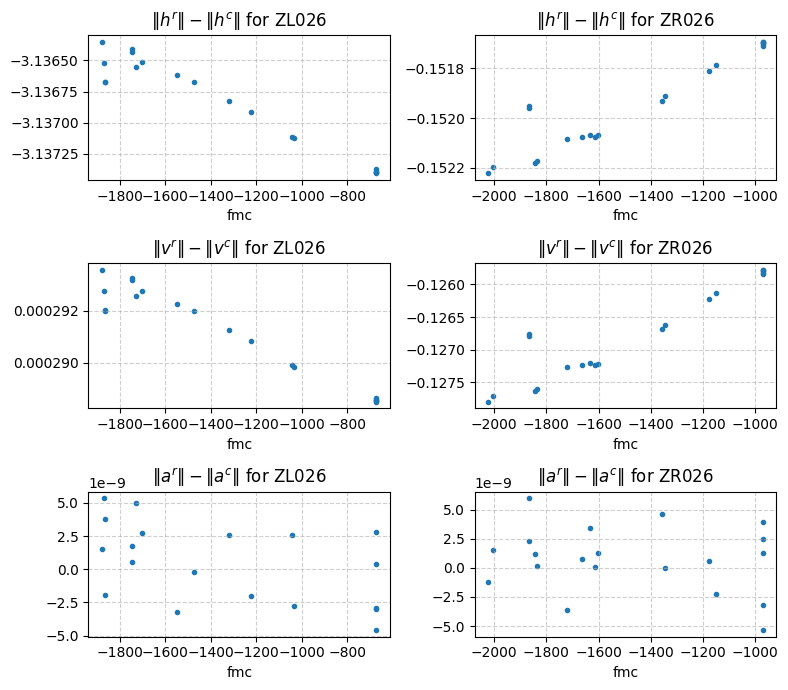

In [30]:
f_str = "026"
zl, zr = get_zl_zr(f_str, data_all)
b1_zl, b2_zl, cx_zl, cy_zl = fits[f"ZL{f_str}"]["b1"], fits[f"ZL{f_str}"]["b2"], fits[f"ZL{f_str}"]["cx"], fits[f"ZL{f_str}"]["cy"]
b1_zr, b2_zr, cx_zr, cy_zr = fits[f"ZR{f_str}"]["b1"], fits[f"ZR{f_str}"]["b2"], fits[f"ZR{f_str}"]["cx"], fits[f"ZR{f_str}"]["cy"]

# here we plot norm(H^r) - norm(H^c) 
fig, ax = plt.subplots(3, 2, figsize=(8,7))

for j, data in enumerate([zl, zr]):
  diffs = []
  for i in range(data.shape[0]):
    fl = data["f_est"].iloc[i]
    b1 = b1_zl if j == 0 else b1_zr
    b2 = b2_zl if j == 0 else b2_zr
    cx = cx_zl if j == 0 else cx_zr
    cy = cy_zl if j == 0 else cy_zr
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    Hr = get_H_r_data(i, data)
    Hr_norm = np.linalg.norm(Hr, axis=0)
    Hc_norm = np.linalg.norm(Hc, axis=0)
    diffs.append(Hr_norm - Hc_norm)

  for k in range(3):
    ax[k, j].scatter(data["fmc"], [diff[k] for diff in diffs], marker='.')
    ax[k, j].set_xlabel("fmc")
    ax[k, j].set_ylabel("")
    ax[k, j].grid(linestyle="--", alpha=0.6)
  
  cam_name = f"ZL{f_str}" if j==0 else f"ZR{f_str}"
  ax[0, j].set_title(f"$\|h^r\|-\|h^c\|$ for {cam_name}")
  ax[1, j].set_title(f"$\|v^r\|-\|v^c\|$ for {cam_name}")
  ax[2, j].set_title(f"$\|a^r\|-\|a^c\|$ for {cam_name}")
  
fig.tight_layout()

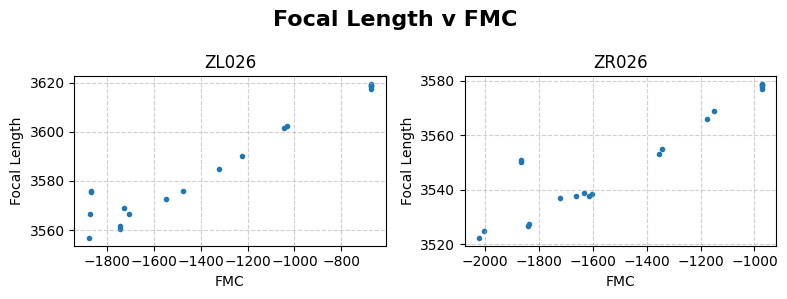

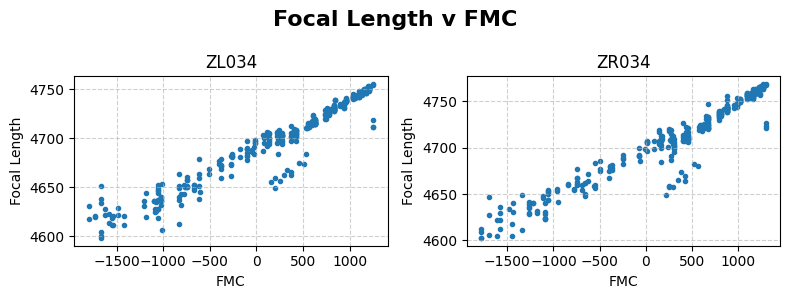

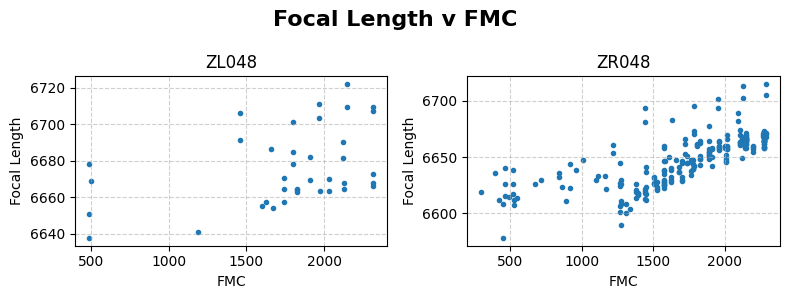

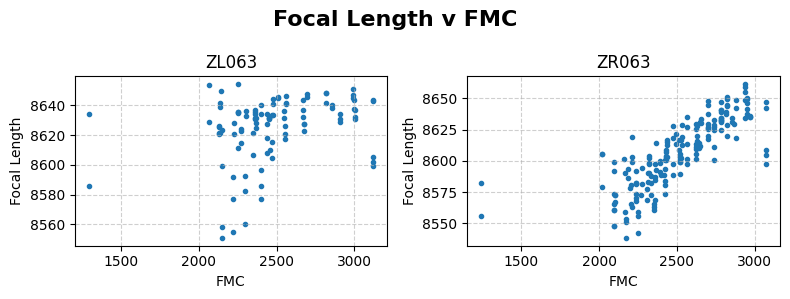

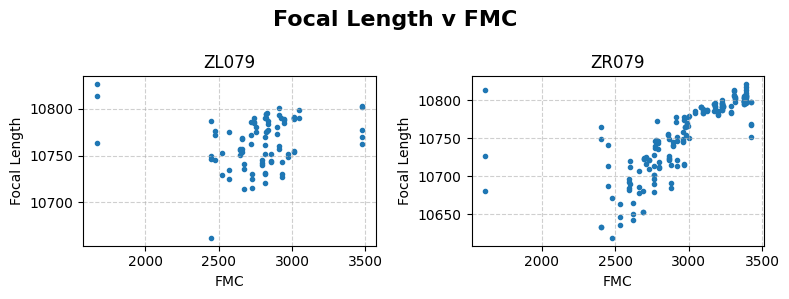

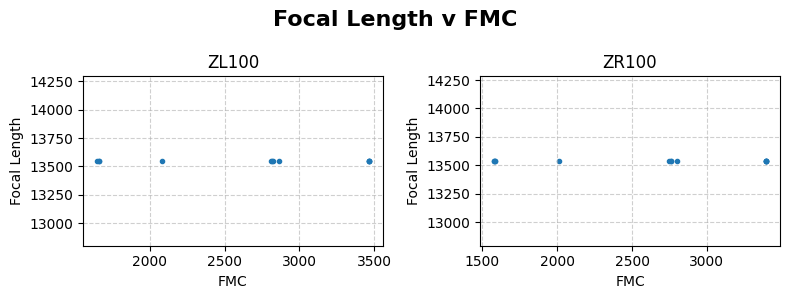

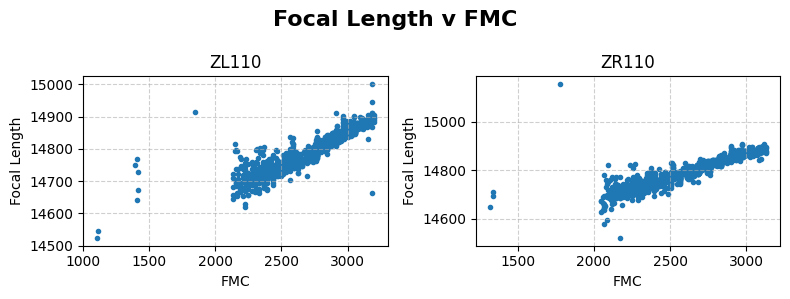

In [32]:
for f_str in f_strs:
  zl, zr = get_zl_zr(f_str, data_all)

  fig, ax = plt.subplots(1,2,figsize=(8, 3))
  for i, data in enumerate([zl, zr]):
    ax[i].scatter(data["fmc"], data["f_est"], marker='.')
    ax[i].set_xlabel("FMC")
    ax[i].set_ylabel("Focal Length")
    ax[i].set_title(f"ZL{f_str}" if i==0 else f"ZR{f_str}")
    ax[i].grid(linestyle="--", alpha=0.6)

  fig.suptitle("Focal Length v FMC", fontweight="bold", fontsize=16)
  fig.tight_layout()